In [4]:
"""
Notebook 03: Momentum Signal
========================================
目标：
1. 计算每只股票每个月底的过去 12 月动量
2. 横截面排名（每月底按动量排序）
3. 识别 winners / losers
4. 可视化动量热力图

关键概念：
- Lookback period: 12 months（动量回看期）
- Skip period: 1 month（学术规范，避开短期反转）
- Holding period: 1 month（持有期，月度再平衡）
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 加载 Day 2 保存的数据
prices = pd.read_csv('../data/prices_panel.csv', index_col=0, parse_dates=True)
returns = pd.read_csv('../data/returns_panel.csv', index_col=0, parse_dates=True)

print(f"价格面板: {prices.shape}")
print(f"收益率面板: {returns.shape}")
print(f"时间范围: {prices.index[0]} 至 {prices.index[-1]}")
print(f"股票数量: {len(prices.columns)}")
print(f"\n前 5 只股票: {list(prices.columns[:5])}")

价格面板: (1588, 31)
收益率面板: (973, 31)
时间范围: 2020-01-02 00:00:00 至 2026-04-28 00:00:00
股票数量: 31

前 5 只股票: ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META']


In [5]:
# 取月末数据（每个月最后一个交易日）
monthly_prices = prices.resample('M').last()

# 月度收益率
monthly_returns = monthly_prices.pct_change()

print(f"月末价格面板: {monthly_prices.shape}")
print(f"月度收益率面板: {monthly_returns.shape}")
print(f"\n前 5 个月末日期:")
print(monthly_prices.index[:5])
print(f"\n最后 5 个月末日期:")
print(monthly_prices.index[-5:])

# 看一下 NVDA 的月度收益（前 12 个月）
print(f"\nNVDA 前 12 个月的月度收益:")
print(monthly_returns['NVDA'].head(12))


月末价格面板: (76, 31)
月度收益率面板: (76, 31)

前 5 个月末日期:
DatetimeIndex(['2020-01-31', '2020-02-29', '2020-03-31', '2020-04-30',
               '2020-05-31'],
              dtype='datetime64[ns]', name='date', freq='ME')

最后 5 个月末日期:
DatetimeIndex(['2025-12-31', '2026-01-31', '2026-02-28', '2026-03-31',
               '2026-04-30'],
              dtype='datetime64[ns]', name='date', freq='ME')

NVDA 前 12 个月的月度收益:
date
2020-01-31         NaN
2020-02-29    0.146630
2020-03-31   -0.024486
2020-04-30    0.111232
2020-05-31    0.218972
2020-06-30    0.071729
2020-07-31    0.119366
2020-08-31    0.263461
2020-09-30    0.012090
2020-10-31   -0.074396
2020-11-30    0.069971
2020-12-31   -0.025819
Freq: ME, Name: NVDA, dtype: float64


In [6]:
def compute_momentum_signal(monthly_prices, lookback=12, skip=1):
    """
    计算每个月底的动量信号
    
    动量定义（学术规范）:
        - lookback = 12: 看过去 12 个月
        - skip = 1: 跳过最近 1 个月（避免短期反转效应）
        - 实际计算: t-12 到 t-1 的累计收益
    
    举例:
        在 2024-12 月底，动量信号 = 
            (2024-11 月底价格 / 2023-11 月底价格) - 1
            = 跳过 12 月当月，看前 12 个月的累计收益
    
    参数:
        monthly_prices: 月末价格面板
        lookback: 回看期（月）
        skip: 跳过最近多少月
    
    返回:
        DataFrame: 每个月底的动量信号
    """
    # 关键: 用 shift 避免前视偏差
    # 在 t 月底，我们只能用 t-1 月底以前的数据
    
    # 价格在 t-skip 月底
    end_price = monthly_prices.shift(skip)
    
    # 价格在 t-skip-lookback 月底
    start_price = monthly_prices.shift(skip + lookback)
    
    # 累计收益
    momentum = end_price / start_price - 1
    
    return momentum


# 计算动量
momentum = compute_momentum_signal(monthly_prices, lookback=12, skip=1)

print(f"动量信号面板: {momentum.shape}")
print(f"\n=== 最近 3 个月的动量信号 ===")
print(momentum.tail(3))
print(f"\n=== 注意: 前 13 个月没有信号（因为需要 12 个月历史 + 1 个月 skip）===")
print(f"前 13 行的 NVDA 动量信号:")
print(momentum['NVDA'].head(13))

动量信号面板: (76, 31)

=== 最近 3 个月的动量信号 ===
                AAPL      MSFT     GOOGL      AMZN      META      NVDA  \
date                                                                     
2026-02-28  0.104427  0.045356  0.664154  0.006816  0.042852  0.592401   
2026-03-31  0.097093 -0.001957  0.840877 -0.010741 -0.026924  0.418916   
2026-04-30  0.147904 -0.004679  0.869701  0.094660 -0.003709  0.609747   

                TSLA      AVGO      ORCL       CRM  ...       CAT        GE  \
date                                                ...                       
2026-02-28  0.063791  0.515353 -0.020769 -0.376171  ...  0.801835  0.518992   
2026-03-31  0.373848  0.624058 -0.114087 -0.342848  ...  1.203031  0.666699   
2026-04-30  0.434442  0.876387  0.067730 -0.300560  ...  1.193113  0.428852   

                 HON       JNJ       PFE       UNH       LLY       XOM  \
date                                                                     
2026-02-28  0.038449  0.537598  0.067296 -0.46

In [7]:
def rank_stocks_by_momentum(momentum_signal):
    """
    每个月底，对所有股票按动量排名
    
    排名规则:
        - 1 = 最强动量（winner）
        - N = 最弱动量（loser）
    
    返回:
        DataFrame: 每个月底每只股票的排名
    """
    # axis=1 表示按行排序（每个月底横截面）
    # ascending=False 表示从大到小（最大动量排第 1）
    ranks = momentum_signal.rank(axis=1, ascending=False)
    return ranks


# 计算排名
ranks = rank_stocks_by_momentum(momentum)

print(f"排名面板: {ranks.shape}")
print(f"\n=== 最近一个月的排名 ===")
last_month = ranks.iloc[-1].sort_values()
print(last_month)
print(f"\n=== 解读 ===")
print(f"排名 1（最强动量）: {last_month.index[0]}")
print(f"排名 31（最弱动量）: {last_month.index[-1]}")

排名面板: (76, 31)

=== 最近一个月的排名 ===
CAT       1.0
AVGO      2.0
GOOGL     3.0
NVDA      4.0
GS        5.0
JNJ       6.0
XOM       7.0
MS        8.0
TSLA      9.0
WMT      10.0
GE       11.0
CVX      12.0
JPM      13.0
BAC      14.0
PFE      15.0
SPY      16.0
BA       17.0
AAPL     18.0
WFC      19.0
LLY      20.0
AMZN     21.0
KO       22.0
HON      23.0
ORCL     24.0
MCD      25.0
META     26.0
MSFT     27.0
HD       28.0
NKE      29.0
CRM      30.0
UNH      31.0
Name: 2026-04-30 00:00:00, dtype: float64

=== 解读 ===
排名 1（最强动量）: CAT
排名 31（最弱动量）: UNH


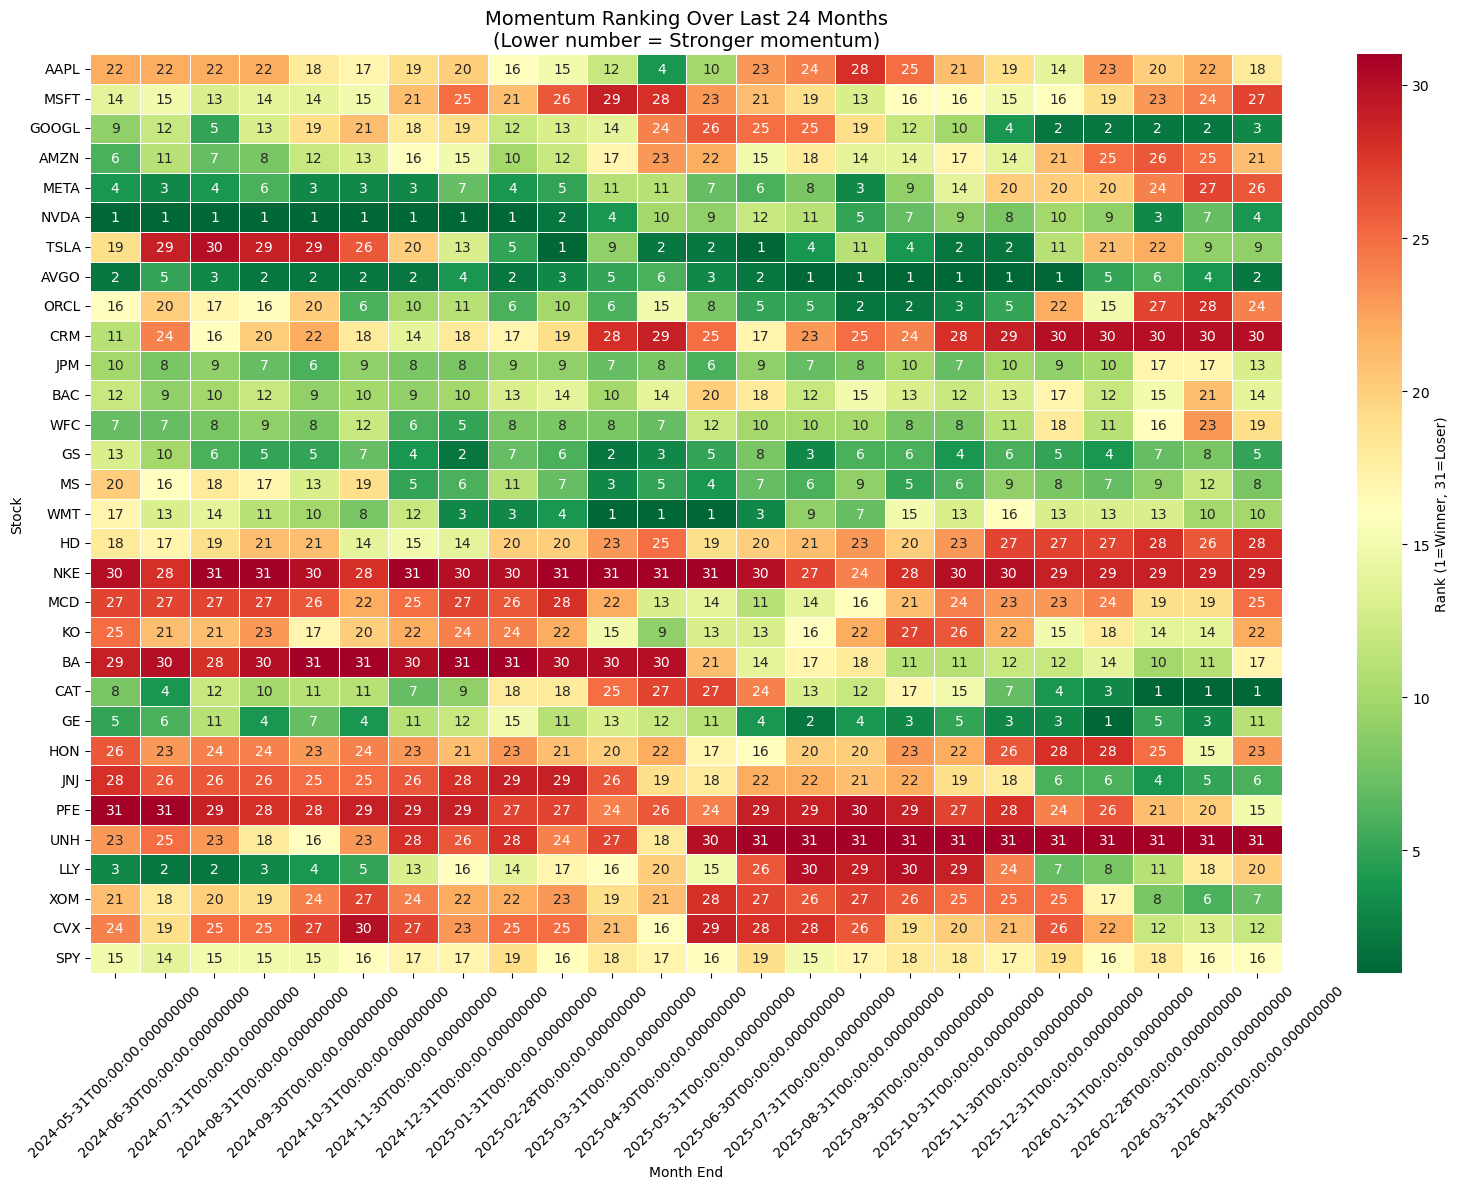


热力图已保存到 reports/03_momentum_heatmap.png


In [8]:
# 取最近 24 个月（2 年）的排名
recent_ranks = ranks.tail(24)

# 转置（行：股票，列：月份）
heatmap_data = recent_ranks.T

# 画热力图
fig, ax = plt.subplots(figsize=(16, 12))

sns.heatmap(
    heatmap_data,
    cmap='RdYlGn_r',  # 红=输家，绿=赢家（_r 表示反向）
    annot=True,        # 显示数字
    fmt='.0f',
    cbar_kws={'label': 'Rank (1=Winner, 31=Loser)'},
    linewidths=0.5,
    ax=ax
)

ax.set_title('Momentum Ranking Over Last 24 Months\n(Lower number = Stronger momentum)', fontsize=14)
ax.set_xlabel('Month End')
ax.set_ylabel('Stock')

# 旋转 x 轴日期
plt.xticks(rotation=45)
plt.tight_layout()

# 保存
import os
os.makedirs('../reports/', exist_ok=True)
plt.savefig('../reports/03_momentum_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n热力图已保存到 reports/03_momentum_heatmap.png")

In [9]:
# 简单预演: 看看"动量赢家"在下一个月的表现
# 注意: 这只是预览，不是完整回测（Day 4 才做完整回测）

# 取每个月底排名前 5 的股票，看下个月收益
top5_next_month_returns = []

for date in ranks.index[:-1]:  # 不包括最后一个月（因为没有下一个月数据）
    if pd.isna(ranks.loc[date]).all():
        continue
    
    # 当月排名前 5
    top5 = ranks.loc[date].nsmallest(5).index.tolist()
    
    # 下个月的索引位置
    next_idx = ranks.index.get_loc(date) + 1
    if next_idx >= len(monthly_returns):
        continue
    next_date = monthly_returns.index[next_idx]
    
    # 下个月这 5 只的平均收益
    next_returns = monthly_returns.loc[next_date, top5].mean()
    top5_next_month_returns.append({
        'signal_date': date,
        'next_month_return': next_returns,
        'top5_stocks': ', '.join(top5)
    })

results = pd.DataFrame(top5_next_month_returns)

print(f"预演结果: {len(results)} 个月的数据")
print(f"\n=== 整体表现 ===")
print(f"平均月度收益: {results['next_month_return'].mean():.2%}")
print(f"年化收益: {results['next_month_return'].mean() * 12:.2%}")
print(f"月度胜率: {(results['next_month_return'] > 0).mean():.2%}")

print(f"\n=== 最近 6 个月的 top 5 选股 ===")
print(results.tail(6).to_string(index=False))

预演结果: 62 个月的数据

=== 整体表现 ===
平均月度收益: 2.30%
年化收益: 27.55%
月度胜率: 66.13%

=== 最近 6 个月的 top 5 选股 ===
signal_date  next_month_return                 top5_stocks
 2025-10-31          -0.037260    AVGO, TSLA, ORCL, GS, GE
 2025-11-30          -0.023586 AVGO, TSLA, GE, GOOGL, ORCL
 2025-12-31           0.049695    AVGO, GOOGL, GE, CAT, GS
 2026-01-31           0.010285    GE, GOOGL, CAT, GS, AVGO
 2026-02-28          -0.064974   CAT, GOOGL, NVDA, JNJ, GE
 2026-03-31           0.123247   CAT, GOOGL, GE, AVGO, JNJ


In [10]:
# === In-Sample（历史回测）===
print("=" * 60)
print("【In-Sample】基于历史信号的回测结果（已经发生）")
print("=" * 60)
print(results.tail(6).to_string(index=False))

print(f"\n样本内整体表现:")
print(f"平均月度收益: {results['next_month_return'].mean():.2%}")
print(f"年化收益: {results['next_month_return'].mean() * 12:.2%}")
print(f"月度胜率: {(results['next_month_return'] > 0).mean():.2%}")

print()
print("=" * 60)
print("【Out-of-Sample】基于最新信号的预测（未来 1 月）")
print("=" * 60)

# 最新一个月的信号
latest_date = ranks.index[-1]
latest_top5 = ranks.iloc[-1].nsmallest(5).index.tolist()

print(f"信号日期: {latest_date.strftime('%Y-%m-%d')}")
print(f"建议持仓 (持有 1 个月): {latest_top5}")
print(f"\n*** 这是预测，未来 1 月的实际收益还不知道 ***")
print(f"*** 等下个月底才能验证 ***")

【In-Sample】基于历史信号的回测结果（已经发生）
signal_date  next_month_return                 top5_stocks
 2025-10-31          -0.037260    AVGO, TSLA, ORCL, GS, GE
 2025-11-30          -0.023586 AVGO, TSLA, GE, GOOGL, ORCL
 2025-12-31           0.049695    AVGO, GOOGL, GE, CAT, GS
 2026-01-31           0.010285    GE, GOOGL, CAT, GS, AVGO
 2026-02-28          -0.064974   CAT, GOOGL, NVDA, JNJ, GE
 2026-03-31           0.123247   CAT, GOOGL, GE, AVGO, JNJ

样本内整体表现:
平均月度收益: 2.30%
年化收益: 27.55%
月度胜率: 66.13%

【Out-of-Sample】基于最新信号的预测（未来 1 月）
信号日期: 2026-04-30
建议持仓 (持有 1 个月): ['CAT', 'AVGO', 'GOOGL', 'NVDA', 'GS']

*** 这是预测，未来 1 月的实际收益还不知道 ***
*** 等下个月底才能验证 ***
